## Enhanced Agentic PageRAG with Elegant Schema Architecture

#### Real-World Applications:
1. **Financial Analysis**: SEC filings (10-K, 10-Q) with automatic company/year/section detection
2. **Legal Research**: Contracts and case law with jurisdiction/date/clause filtering  
3. **Medical Records**: Patient documents with date/provider/department filters
4. **Enterprise Docs**: Multi-project knowledge base with org/dept/category filters
5. **Research Papers**: Academic search with author/year/topic/section filters

In [ ]:
# Repeating SOme Initial Steps for Colab Setup
from google.colab import drive
drive.mount('/content/drive')

# Verify Ollama is running:
!nohup ollama serve > ollama.log 2>&1 &
!ollama list

# check the contents of the cloned repo
%cd Retrieval-Augmented-Generation-LangGraph-Ollama

# check the contents of the RAG_Applications folder
!ls

# Final Check
import langchain
print("OK")

In [ ]:
import os
from google.colab import userdata

# Load API key from Colab secrets
os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")

# Non-sensitive configs
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com/"
os.environ["LANGCHAIN_PROJECT"] = "Retrieval-Augmented-Generation-LangGraph-Ollama"

True

In [3]:
from typing_extensions import TypedDict, Annotated
import operator
import os

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool

# render markdown content in Notebook
from IPython.display import display, Markdown

from scripts import utils

In [ ]:
# =============================================================================
# Configuration
# =============================================================================
DATA_DIR = "/content/Retrieval-Augmented-Generation-LangGraph-Ollama/RAG_Applications/data"
CHROMA_DIR = "/content/drive/MyDrive/chroma_financial_db"
COLLECTION_NAME = "financial_docs"
EMBEDDING_MODEL = 'embeddinggemma:300m'
BASE_URL = 'http://127.0.0.1:11434'
LLM_MODEL = "mistral:7b"
DEBUG_PATH = "/content/drive/MyDrive/debug_logs"

llm = ChatOllama(
        model=LLM_MODEL,
        base_url=BASE_URL
    )

In [5]:
utils.extract_filters("what is amazon's cashflow in 2024")

{'company_name': 'amazon', 'fiscal_year': 2024}

In [6]:
# =============================================================================
# State Definition
# =============================================================================

class AgentState(TypedDict):
    messages: Annotated[list, operator.add]

### Retriever Tool

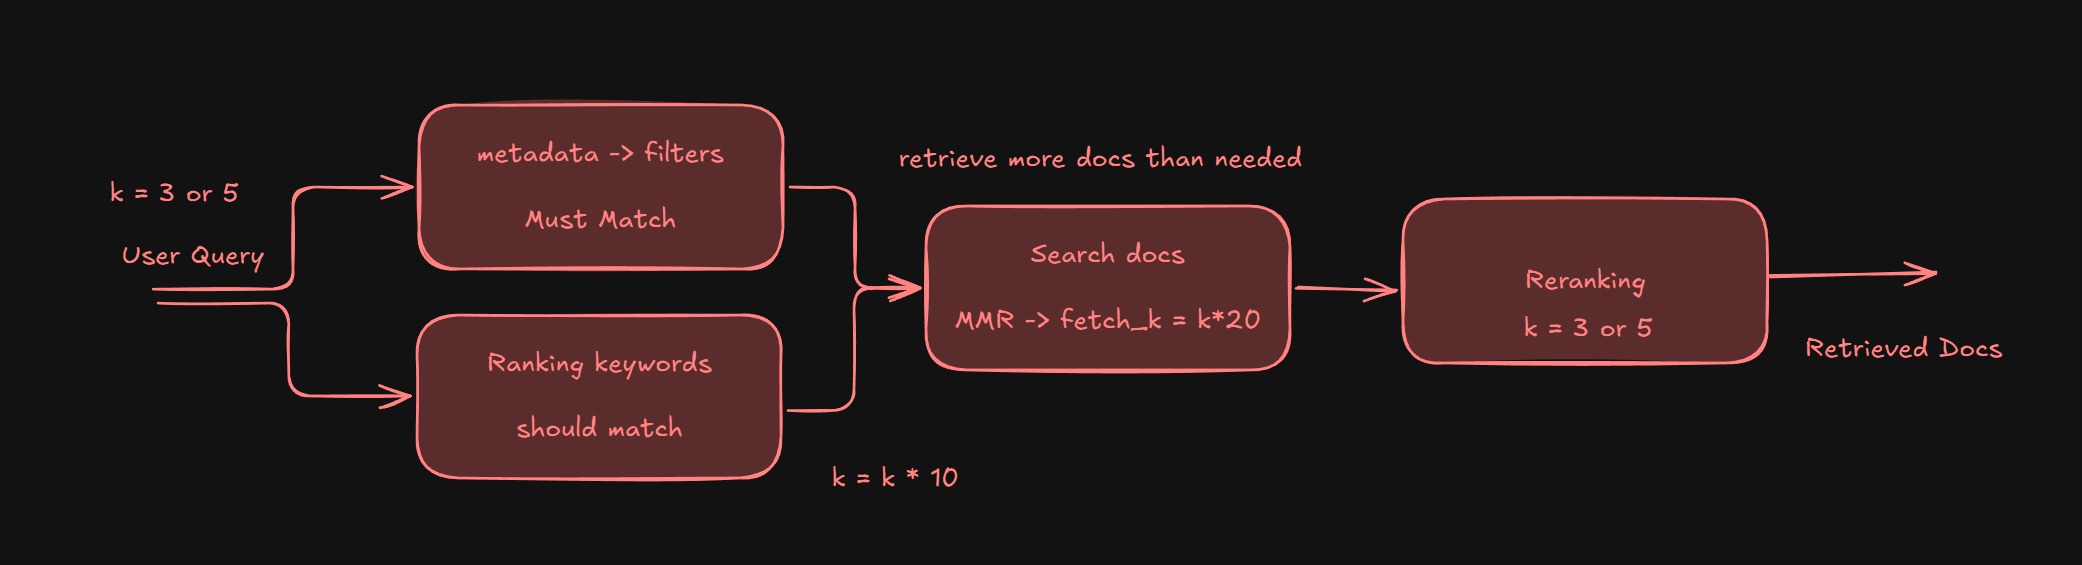

In [ ]:
@tool
def retrieve_docs(query:str, k=5):
    """
    Retrieve relevant financial documents from ChromaDB.
    Extracts filters from query and retrieves matching documents.

    Args:
        query: The search query (e.g., "What was Amazon's revenue in Q2 2025?")
        k: Number of documents to retrieve. generally prefer 5 docs

    Returns:
        Retrieved documents with metadata as formatted string
    """
    print(f"\n[TOOL] retrieve_docs called")
    print(f"[QUERY] {query}")

    filters = utils.extract_filters(query)
    ranking_keywords = utils.generate_ranking_keywords(query)

    # fetch more docs than needed for better re-ranking
    results = utils.search_docs(query, filters, ranking_keywords, k=10*k)

    # rank retrieved docs
    docs = utils.rank_documents_by_keywords(results, ranking_keywords, k=k)

    print(f"[RETRIEVED] {len(docs)} documents")

    # format extracted docs or chunks
    if len(docs)==0:
        return f"No ducuments found for the query: '{query}'. Try rephrasing query or use different filter."
    
    # final format
    # --- Document {i} ---
    retrieved_text = []
    for i, doc in enumerate(docs, 1):
        doc_text = [f"--- Document {i} ---"]

        # add all metadata
        for key, value in doc.metadata.items():
            doc_text.append(f"{key}: {value}")

        # add content
        doc_text.append(f"\nContent:\n{doc.page_content}")

        text = "\n".join(doc_text)
        retrieved_text.append(text)

    retrieved_text = "\n".join(retrieved_text)

    os.makedirs(DEBUG_PATH, exist_ok=True)
    with open(f"{DEBUG_PATH}/retrieved_reranked_docs.md", "w", encoding="utf-8") as f:
        f.write(retrieved_text)

    return retrieved_text


In [8]:
query = "what is amazon's revenue in 2024?"
result = retrieve_docs.invoke(query)


[TOOL] retrieve_docs called
[QUERY] what is amazon's revenue in 2024?
   [1] Doc 18: score=21.5508
   [2] Doc 11: score=20.9299
   [3] Doc 9: score=20.6941
   [4] Doc 1: score=19.3327
   [5] Doc 10: score=17.7692
[RETRIEVED] 5 documents


### Agent Node

In [9]:
# =============================================================================
# Agent Node
# =============================================================================

def agent_node(state: AgentState):

    messages = state['messages']

    tools = [retrieve_docs]
    llm_with_tools = llm.bind_tools(tools)

    system_prompt = """You are a financial document analysis assistant with access to a document retrieval tool.

                CRITICAL RULES:
                1. ALWAYS use the retrieve_docs tool first - NEVER answer from memory
                2. You MUST call the tool before providing any financial information
                3. Answer ONLY based on the retrieved documents
                4. If documents don't contain the answer, clearly state that

                WORKFLOW FOR SIMPLE QUESTIONS:
                Step 1: Call retrieve_docs tool with the user's question
                Step 2: Wait for the tool results
                Step 3: Analyze the retrieved documents
                Step 4: Provide answer with citations (company, year, quarter, page)

                WORKFLOW FOR COMPLEX/COMPARISON QUESTIONS:
                Step 1: Break down the question into sub-questions
                Example: "Compare Amazon and Google revenue" -> 
                - Sub-question 1: "Amazon revenue"
                - Sub-question 2: "Google revenue"

                Step 2: Call retrieve_docs for EACH sub-question separately
                - First call for Amazon
                - Wait for results
                - Second call for Google
                - Wait for results

                Step 3: Analyze all retrieved documents

                Step 4: Present comparison in TABLE format:
                | Metric | Company A | Company B |
                |--------|-----------|-----------|
                | Revenue | $X | $Y |

                ANSWER FORMATTING (Use Markdown):
                - Use **headings** (##, ###) for sections
                - Use paragraphs for detailed findings and reasonings
                - Use **bullet points** for lists
                - Use **tables** for comparisons and structured data
                - Use **bold** for emphasis on key metrics
                - Cite sources: (Company: X, Year: Y, Quarter: Z, Page: N)

                EXAMPLES:

                Example 1 - Simple Question:
                User: "What was Amazon's revenue in Q2 2025?"
                You: [Call tool] -> [Analyze docs] -> 
                "## Amazon Q2 2025 Revenue

                Amazon's revenue for Q2 2025 was **$XXX billion**

                **Source:** Amazon, 2025, Q2, Page 5"

                Example 2 - Comparison Question:
                User: "Compare Amazon and Google revenue"
                You: [Call tool for Amazon] -> [Call tool for Google] -> [Analyze both] ->
                "## Revenue Comparison

                | Company | Revenue | Year | Quarter |
                |---------|---------|------|---------|
                | Amazon  | $XXX B  | 2025 | Q2      |
                | Google  | $YYY B  | 2025 | Q2      |

                **Analysis:**
                - Amazon's revenue was higher by $ZZZ billion
                - Google showed XX% growth

                **Sources:**
                - Amazon: 2025, Q2, Page 5
                - Google: 2025, Q2, Page 8"

                Example 3 - Multi-part Question:
                User: "What are Amazon's revenue, profit, and cash flow?"
                You: [Call tool] -> [Analyze docs] ->
                "## Amazon Financial Metrics

                ### Revenue
                - Q2 2025: $XXX billion

                ### Profit  
                - Q2 2025: $YYY billion

                ### Cash Flow
                - Q2 2025: $ZZZ billion

                **Source:** Amazon, 2025, Q2, Pages 5-7"

                REMEMBER:
                - ALWAYS call the tool first
                - Break complex questions into sub-questions
                - Use tables for comparisons
                - Format answers in detailed Markdown
                - Always cite sources
                - If no relevant documents are found, try with different filters."""
    
    system_msg = SystemMessage(system_prompt)

    messages = [system_msg] + messages

    response = llm_with_tools.invoke(messages)

    if hasattr(response, 'tool_calls') and response.tool_calls:
        for tc in response.tool_calls:
            print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
    else:
        print(f"[AGENT] Responding...")


    return {'messages': [response]}



### Routing

In [10]:
def should_continue(state: AgentState):
    last = state['messages'][-1]
    
    if hasattr(last, 'tool_calls') and last.tool_calls:
        return "tools"
    

    else:
        return END

### Graph Creation

In [11]:
def create_agent():

    builder = StateGraph(AgentState)

    builder.add_node('agent', agent_node)
    builder.add_node('tools', ToolNode([retrieve_docs]))

    # create edges
    builder.add_edge(START, 'agent')
    builder.add_conditional_edges('agent', should_continue, ['tools', END])
    builder.add_edge('tools', 'agent')

    graph = builder.compile()

    return graph

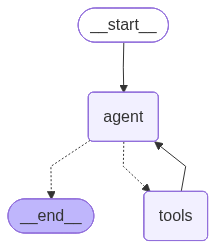

In [12]:
agent = create_agent()
agent

In [13]:
query = "what is the amazon's revenue in 2023?"

result = agent.invoke({'messages': [HumanMessage(query)]})

[AGENT] called Tool retrieve_docs with args {'k': 5, 'query': "Amazon's revenue in 2023"}

[TOOL] retrieve_docs called
[QUERY] Amazon's revenue in 2023
   [1] Doc 17: score=23.4068
   [2] Doc 3: score=22.7389
   [3] Doc 8: score=20.1882
   [4] Doc 14: score=19.2649
   [5] Doc 5: score=18.0985
[RETRIEVED] 5 documents
[AGENT] Responding...


In [14]:
result

{'messages': [HumanMessage(content="what is the amazon's revenue in 2023?", additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'mistral:7b', 'created_at': '2025-11-15T07:25:22.1613714Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2322295700, 'load_duration': 65282300, 'prompt_eval_count': 1069, 'prompt_eval_duration': 106241300, 'eval_count': 250, 'eval_duration': 2080335600, 'model_name': 'mistral:7b', 'model_provider': 'ollama'}, id='lc_run--b7e782ca-2a72-4b68-9ccb-1f88574e4e96-0', tool_calls=[{'name': 'retrieve_docs', 'args': {'k': 5, 'query': "Amazon's revenue in 2023"}, 'id': '710eb479-5a5e-4857-bb63-29bf16cbbc8a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1069, 'output_tokens': 250, 'total_tokens': 1319}),
  ToolMessage(content="--- Document 1 ---\nfiscal_year: 2023\ndoc_type: 10-k\npage: 20\nfile_hash: 6e5549c7b20b0fbc5f482397070a1e85cbf8643c801ff570903f52366b11154f\nsource_file: amazon 

In [15]:
result['messages'][-1].pretty_print()

display(Markdown(result['messages'][-1].content))

================================== Ai Message ==================================

## Amazon's 2023 Revenue

Amazon's total revenue for 2023 was **$574.785 billion**, as reported in its consolidated net sales figures from the 10-K filing.

### Key Details:
- **Consolidated Net Sales**: $574,785 million (Table in Document 2, Page 24)
- **Year-over-Year Growth**: 12% increase compared to 2022
- **Segment Breakdown**:
  - North America: $352.828 billion (61% of total)
  - International: $131.200 billion (23% of total)
  - AWS: $90.757 billion (16% of total)

### Sources:
- **Document 2**: Amazon 10-K 2023, Page 24, Section "Results of Operations - Net Sales"  
  *(Cites: Amazon, 2023, Year, Page 24)*

This figure represents the sum of product and service sales across all segments, including AWS, North America, and International operations. The 12% growth reflects increased unit sales, advertising revenue, and subscription services.


## Amazon's 2023 Revenue

Amazon's total revenue for 2023 was **$574.785 billion**, as reported in its consolidated net sales figures from the 10-K filing.

### Key Details:
- **Consolidated Net Sales**: $574,785 million (Table in Document 2, Page 24)
- **Year-over-Year Growth**: 12% increase compared to 2022
- **Segment Breakdown**:
  - North America: $352.828 billion (61% of total)
  - International: $131.200 billion (23% of total)
  - AWS: $90.757 billion (16% of total)

### Sources:
- **Document 2**: Amazon 10-K 2023, Page 24, Section "Results of Operations - Net Sales"  
  *(Cites: Amazon, 2023, Year, Page 24)*

This figure represents the sum of product and service sales across all segments, including AWS, North America, and International operations. The 12% growth reflects increased unit sales, advertising revenue, and subscription services.

In [16]:
query = "what is the revenue of amazon's and google in 2023?"

result = agent.invoke({'messages': [HumanMessage(query)]})

display(Markdown(result['messages'][-1].content))

[AGENT] called Tool retrieve_docs with args {'k': 5, 'query': 'Amazon revenue 2023'}
[AGENT] called Tool retrieve_docs with args {'k': 5, 'query': 'Google revenue 2023'}

[TOOL] retrieve_docs called
[QUERY] Amazon revenue 2023

[TOOL] retrieve_docs called
[QUERY] Google revenue 2023
   [1] Doc 22: score=27.1283
   [2] Doc 5: score=24.9425
   [3] Doc 2: score=24.1044
   [4] Doc 38: score=22.6427
   [5] Doc 34: score=22.1474
[RETRIEVED] 5 documents
   [1] Doc 20: score=23.4068
   [2] Doc 3: score=22.7389
   [3] Doc 7: score=20.1882
   [4] Doc 13: score=19.2649
   [5] Doc 5: score=18.0985
[RETRIEVED] 5 documents
[AGENT] Responding...


## Revenue Comparison: Amazon vs. Google in 2023

| **Metric**         | **Amazon**              | **Google**               |
|---------------------|-------------------------|--------------------------|
| **Total Revenue**   | $574,785 million        | $307,394 million         |
| **Source**          | Amazon 10-K 2023, Page 24 | Google 10-K 2023, Page 64 |
| **Fiscal Year**     | 2023                    | 2023                     |

### Analysis:
- **Amazon** reported **$574.8 billion** in total revenue for 2023, driven by its retail, AWS, and advertising segments (as detailed in its consolidated financial statements).
- **Google** (Alphabet Inc.) reported **$307.4 billion** in total revenue for 2023, primarily from its Google Services, Google Cloud, and Other Bets segments (as outlined in its disaggregated revenue table).

### Key Context:
- Amazon's revenue is significantly higher, reflecting its broader retail and logistics ecosystem, including AWS (which contributed $90.8 billion in 2023).
- Google's revenue is dominated by its advertising business (Google Search, YouTube, and Google Network), with cloud and other emerging ventures contributing additional growth. 

**Sources:**  
- Amazon: 2023, Page 24 (10-K filing)  
- Google: 2023, Page 64 (10-K filing)